In [1]:
import numpy as np
import os
import xarray as xr
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point, LineString, Polygon
from shapely.ops import unary_union
from sklearn.cluster import KMeans
from meshkernel import MeshKernel, GeometryList, OrthogonalizationParameters, ProjectToLandBoundaryOption, MeshRefinementParameters

from hecras_mesh_data import HECRASMeshData, extract_ghost_nodes

### Original Data Mesh

In [2]:
netcdf_file = f'raw_datasets_mesh/Simulations/output_{1}_map.nc'
nc_dataset = xr.open_dataset(netcdf_file)

In [3]:
node_x = nc_dataset['mesh2d_node_x'].data
node_y = nc_dataset['mesh2d_node_y'].data

face_x = nc_dataset['mesh2d_face_x'].data
face_y = nc_dataset['mesh2d_face_y'].data

edge_index = nc_dataset['mesh2d_edge_nodes'].data.T - 1
edge_type = nc_dataset['mesh2d_edge_type'].data # 1:normal edges, 2:BC_edge, 3:other boundary edges
dual_edge_index = nc_dataset['mesh2d_edge_faces'].data.T.astype(int) - 1

face_nodes = nc_dataset['mesh2d_face_nodes'] - 1

In [4]:
# nc_dataset['mesh2d_face_nodes'].data[:, 0:3].astype(int) - 1

In [5]:
print('Shape of node_x:', node_x.shape)
print('Shape of node_y:', node_y.shape)
print('Shape of face_x:', face_x.shape)
print('Shape of face_y:', face_y.shape)
print('Shape of edge_index:', edge_index.shape)
print('Range of edge_index:', edge_index.min(), 'to', edge_index.max())
print('Shape of edge_type:', edge_type.shape)
print('Range of edge_type:', edge_type.min(), 'to', edge_type.max())
print('Shape of dual_edge_index:', dual_edge_index.shape)
print('Range of dual_edge_index:', dual_edge_index.min(), 'to', dual_edge_index.max())
print('Shape of face_nodes:', face_nodes.shape)

Shape of node_x: (4803,)
Shape of node_y: (4803,)
Shape of face_x: (9399,)
Shape of face_y: (9399,)
Shape of edge_index: (2, 14201)
Range of edge_index: 0 to 4802
Shape of edge_type: (14201,)
Range of edge_type: 1.0 to 3.0
Shape of dual_edge_index: (2, 14201)
Range of dual_edge_index: -1 to 9398
Shape of face_nodes: (9399, 4)


In [6]:
def create_gdfs_from_mesh_properties(node_x, node_y, face_x, face_y, edge_index, edge_type, dual_edge_index, face_nodes):
    # Create nodes as Point geometries
    nodes_geom = [Point(x, y) for x, y in zip(node_x, node_y)]
    face_points_gdf = gpd.GeoDataFrame({'node_id': range(len(node_x))}, geometry=nodes_geom)

    # Create faces as Polygon geometries
    faces_geom = []
    for i in range(len(face_x)):
        # Get the node indices for this face
        if isinstance(face_nodes, xr.DataArray):
            face_node_indices = face_nodes[i].values
        else:
            face_node_indices = face_nodes[i]
        # Filter out fill values (typically -1 or NaN)
        face_node_indices = face_node_indices[face_node_indices >= 0]
        # Get coordinates for these nodes
        coords = [(node_x[int(idx)], node_y[int(idx)]) for idx in face_node_indices]
        if len(coords) >= 3:  # Need at least 3 points to form a polygon
            faces_geom.append(Polygon(coords))
        else:
            faces_geom.append(None)
            
    face_edges_gdf = gpd.GeoDataFrame({'face_id': range(len(face_x))}, geometry=faces_geom)

    # Create face centers as Point geometries
    face_centers_geom = [Point(x, y) for x, y in zip(face_x, face_y)]
    face_centers_gdf = gpd.GeoDataFrame({'face_id': range(len(face_x))}, geometry=face_centers_geom)

    # Create edges (connecting nodes) as LineString geometries
    edges_geom = []
    for i in range(edge_index.shape[1]):
        node1_idx, node2_idx = edge_index[0, i], edge_index[1, i]
        if node1_idx >= 0 and node2_idx >= 0:  # Valid edge
            line = LineString([(node_x[node1_idx], node_y[node1_idx]), 
                            (node_x[node2_idx], node_y[node2_idx])])
            edges_geom.append(line)
        else:
            edges_geom.append(None)

    edges_gdf = gpd.GeoDataFrame({
        'edge_id': range(len(edges_geom)),
        'edge_type': edge_type.astype(int),
    }, geometry=edges_geom)

    # Create dual edges (connecting face centers) as LineString geometries
    dual_edges_geom = []
    for i in range(dual_edge_index.shape[1]):
        face1_idx, face2_idx = dual_edge_index[0, i], dual_edge_index[1, i]
        if face1_idx >= 0 and face2_idx >= 0:  # Valid dual edge
            line = LineString([(face_x[face1_idx], face_y[face1_idx]), 
                            (face_x[face2_idx], face_y[face2_idx])])
            dual_edges_geom.append(line)
        else:
            dual_edges_geom.append(None)
            
    dual_edges_gdf = gpd.GeoDataFrame({
        'dual_edge_id': range(len(dual_edges_geom))
    }, geometry=dual_edges_geom)

    return face_points_gdf, face_edges_gdf, face_centers_gdf, edges_gdf, dual_edges_gdf

face_points_gdf, face_edges_gdf, face_centers_gdf, edges_gdf, dual_edges_gdf = create_gdfs_from_mesh_properties(
    node_x, node_y, face_x, face_y, edge_index, edge_type, dual_edge_index, face_nodes
)

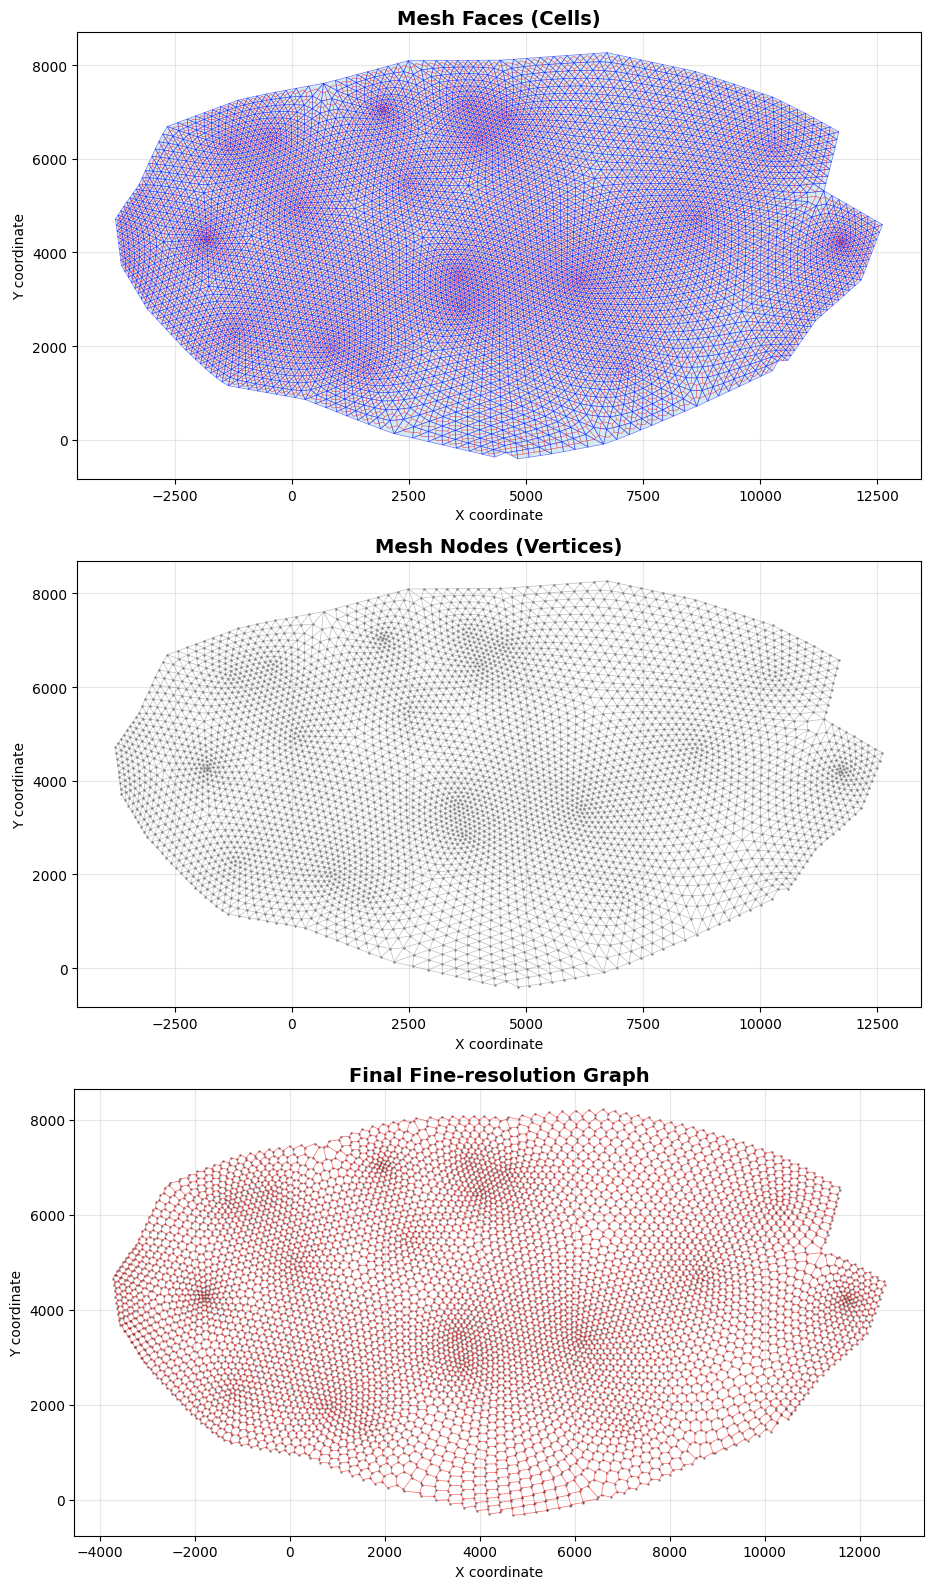

In [7]:
# Plot the mesh
fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# Plot 1: Faces (mesh cells)
ax1 = axes[0]
face_edges_gdf.plot(ax=ax1, facecolor='lightblue', edgecolor='blue', alpha=0.5, linewidth=0.5)
dual_edges_gdf.plot(ax=ax1, color='red', linewidth=0.5, alpha=0.6)
# face_centers_gdf.plot(ax=ax1, color='green', markersize=2, alpha=0.3)
ax1.set_title('Mesh Faces (Cells)', fontsize=14, fontweight='bold')
ax1.set_xlabel('X coordinate')
ax1.set_ylabel('Y coordinate')
ax1.grid(True, alpha=0.3)

# Plot 2: Nodes (mesh vertices)
ax2 = axes[1]
face_points_gdf.plot(ax=ax2, color='black', markersize=1, alpha=0.3)
edges_gdf.plot(ax=ax2, color='gray', linewidth=0.5, alpha=0.5)
ax2.set_title('Mesh Nodes (Vertices)', fontsize=14, fontweight='bold')
ax2.set_xlabel('X coordinate')
ax2.set_ylabel('Y coordinate')
ax2.grid(True, alpha=0.3)

# Plot 3: Final Graph Generated
ax3 = axes[2]
# faces_gdf.plot(ax=ax3, facecolor='lightblue', edgecolor='blue', alpha=0.3, linewidth=0.5)
dual_edges_gdf.plot(ax=ax3, color='red', linewidth=0.5, alpha=0.6)
face_centers_gdf.plot(ax=ax3, color='black', markersize=1, alpha=0.3)
ax3.set_title('Final Fine-resolution Graph', fontsize=14, fontweight='bold')
ax3.set_xlabel('X coordinate')
ax3.set_ylabel('Y coordinate')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [8]:
edges_gdf.edge_type.value_counts()

edge_type
1    14001
3      199
2        1
Name: count, dtype: int64

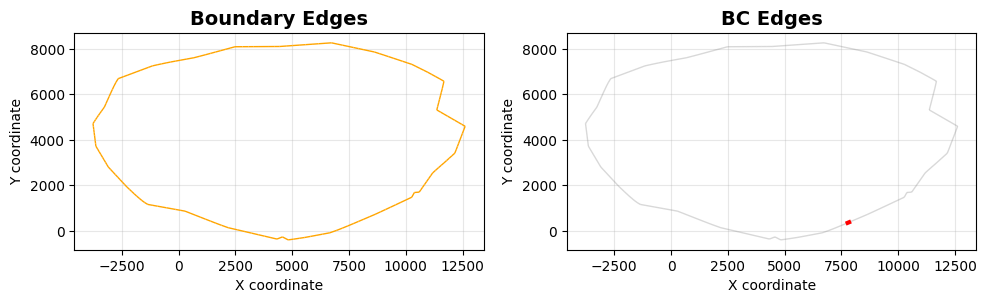

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(10, 12))

ax1 = axes[0]
boundary_edges = edges_gdf[edges_gdf['edge_type'] > 1]
boundary_edges.plot(ax=ax1, color='orange', linewidth=1)
ax1.set_title('Boundary Edges', fontsize=14, fontweight='bold')
ax1.set_xlabel('X coordinate')
ax1.set_ylabel('Y coordinate')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
bc_edges = edges_gdf[edges_gdf['edge_type'] == 2]
boundary_edges.plot(ax=ax2, color='gray', linewidth=1, alpha=0.3)
bc_edges.plot(ax=ax2, color='red', linewidth=3)
ax2.set_title('BC Edges', fontsize=14, fontweight='bold')
ax2.set_xlabel('X coordinate')
ax2.set_ylabel('Y coordinate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

BC dual edge indices (face1 = -1): (2, 1)
Extra BC dual edge indices (face2 = -1): (2, 199)


[]

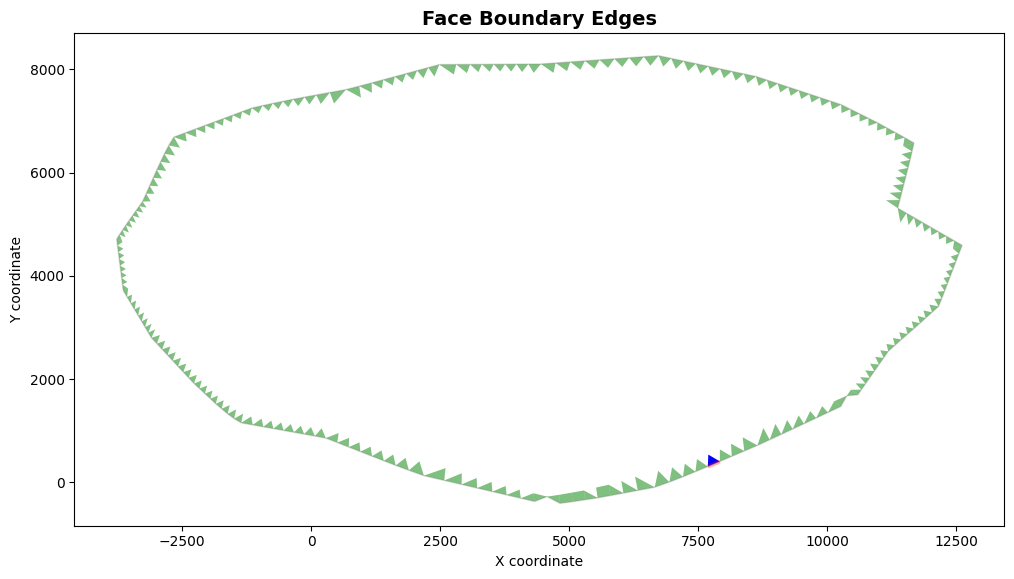

In [10]:
bc_dual_edge_index = dual_edge_index[:, dual_edge_index[0, :] == -1]
extra_bc_dual_edge_index = dual_edge_index[:, dual_edge_index[1, :] == -1]

print('BC dual edge indices (face1 = -1):', bc_dual_edge_index.shape)
print('Extra BC dual edge indices (face2 = -1):', extra_bc_dual_edge_index.shape)

bc_face = face_edges_gdf[face_edges_gdf['face_id'].isin(bc_dual_edge_index[1, :])]
extra_bc_face = face_edges_gdf[face_edges_gdf['face_id'].isin(extra_bc_dual_edge_index[0, :])]

fig, ax = plt.subplots(1, 1, figsize=(12, 12))
boundary_edges.plot(ax=ax, color='gray', linewidth=1, alpha=0.3)
bc_edges.plot(ax=ax, color='red', linewidth=3, alpha=0.3)
bc_face.plot(ax=ax, color='blue', linewidth=3)
extra_bc_face.plot(ax=ax, color='green', linewidth=3, alpha=0.5)
plt.title('Face Boundary Edges', fontsize=14, fontweight='bold')
plt.xlabel('X coordinate')
plt.ylabel('Y coordinate')
plt.plot()


### Downsampling for HEC-RAS data

In [11]:
base_dir = 'C:/Users/Carlo/Documents/School/Masters/NUS/Dissertation/flood_pi_gnn/data/datasets/raw/New_Geometry/'
nodes_path = os.path.join(base_dir, 'cell_centers_with_ele.shp')
links_path = os.path.join(base_dir, 'links_with_slope.shp')
face_path = os.path.join(base_dir, 'faces.shp')
fp_path = os.path.join(base_dir, 'facepoints.shp')

hecras_path = "C:\\Users\\Carlo\\Documents\\School\\Masters\\NUS\\Dissertation\\flood_pi_gnn\\data\\datasets\\raw\\HEC-RAS Results\\Model_01.p43.hdf"

In [12]:
face_centers_gdf = gpd.read_file(nodes_path)
links_gdf = gpd.read_file(links_path)
face_edges_gdf = gpd.read_file(face_path)
fp_gdf = gpd.read_file(fp_path)

# Previous extract ghost nodes
# hec = h5py.File(hecras_path, 'r')
# min_elevation = np.array(hec['Geometry']['2D Flow Areas']['Perimeter 1']['Cells Minimum Elevation']) 
# Ghost_cells_idx = np.where(np.isnan(min_elevation))[0]
# nodes_gdf = nodes_gdf.drop(index=Ghost_cells_idx).reset_index(drop=True)

# ghost_edges_mask = (links_gdf['from_node'].isin(Ghost_cells_idx) | links_gdf['to_node'].isin(Ghost_cells_idx))
# links_gdf = links_gdf[~ghost_edges_mask].reset_index(drop=True)

ghost_nodes = extract_ghost_nodes(hecras_path, face_centers_gdf)

In [13]:
# Create HECRASMeshData from GeoDataFrames
mesh_data = HECRASMeshData.from_gdfs(
    nodes_gdf=face_centers_gdf,
    edges_gdf=links_gdf,
    faces_gdf=face_edges_gdf,
    facepoints_gdf=fp_gdf,
    ghost_nodes=ghost_nodes,
    inflow_bc_nodes=[1248],
)

# Print metrics
print('Shape of node_x:', mesh_data.node_x.shape)
print('Shape of node_y:', mesh_data.node_y.shape)
print('Shape of face_x:', mesh_data.face_x.shape)
print('Shape of face_y:', mesh_data.face_y.shape)
print('Shape of edge_index:', mesh_data.edge_index.shape)
print('Range of edge_index:', mesh_data.edge_index.min(), 'to', mesh_data.edge_index.max())
print('Shape of edge_type:', mesh_data.edge_type.shape)
print('Range of edge_type:', mesh_data.edge_type.min(), 'to', mesh_data.edge_type.max())
print('Shape of dual_edge_index:', mesh_data.dual_edge_index.shape)
print('Range of dual_edge_index:', mesh_data.dual_edge_index.min(), 'to', mesh_data.dual_edge_index.max())
# print('Shape of face_nodes:', mesh_data.face_nodes.shape)

Shape of node_x: (1487,)
Shape of node_y: (1487,)
Shape of face_x: (1126,)
Shape of face_y: (1126,)
Shape of edge_index: (2, 2612)
Range of edge_index: 0 to 1486
Shape of edge_type: (2612,)
Range of edge_type: 1 to 3
Shape of dual_edge_index: (2, 2470)
Range of dual_edge_index: 0 to 1125


In [14]:
hec_face_points_gdf, hec_face_edges_gdf, hec_face_centers_gdf, hec_edges_gdf, hec_dual_edges_gdf = create_gdfs_from_mesh_properties(
    mesh_data.node_x, mesh_data.node_y, mesh_data.face_x, mesh_data.face_y, mesh_data.edge_index, mesh_data.edge_type, mesh_data.dual_edge_index, mesh_data.face_nodes
)

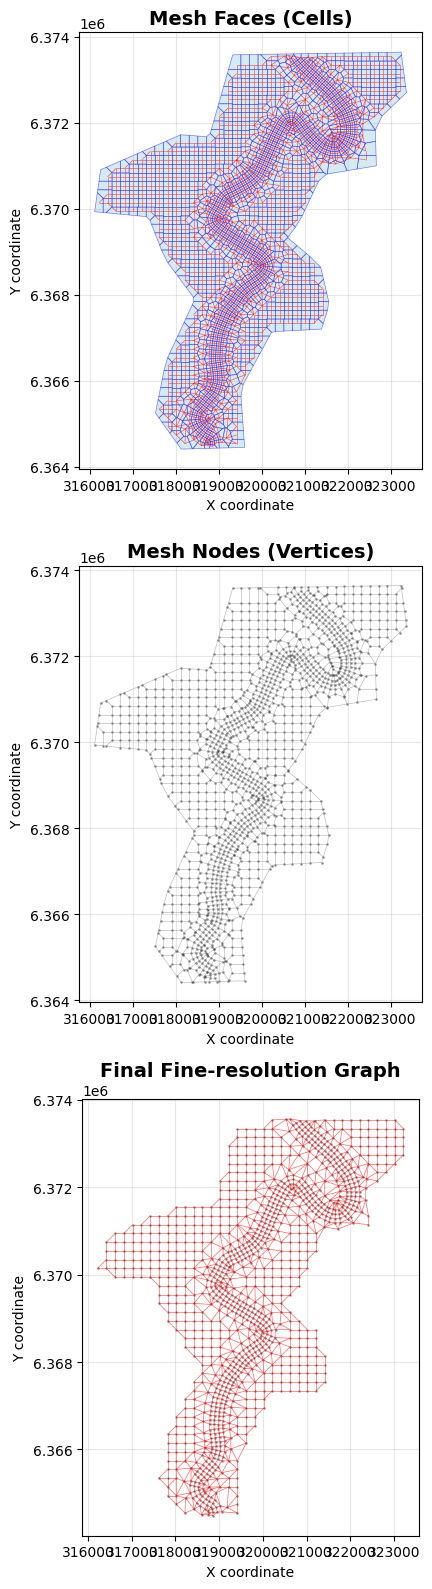

In [29]:
# Plot to double check if it matches
fig, axes = plt.subplots(3, 1, figsize=(16, 16))

# Plot 1: Faces (mesh cells)
ax1 = axes[0]
hec_face_edges_gdf.plot(ax=ax1, facecolor='lightblue', edgecolor='blue', alpha=0.5, linewidth=0.5)
hec_dual_edges_gdf.plot(ax=ax1, color='red', linewidth=0.5, alpha=0.6)
ax1.set_title('Mesh Faces (Cells)', fontsize=14, fontweight='bold')
ax1.set_xlabel('X coordinate')
ax1.set_ylabel('Y coordinate')
ax1.grid(True, alpha=0.3)

# Plot 2: Nodes (mesh vertices)
ax2 = axes[1]
hec_face_points_gdf.plot(ax=ax2, color='black', markersize=1, alpha=0.3)
hec_edges_gdf.plot(ax=ax2, color='gray', linewidth=0.5, alpha=0.5)
ax2.set_title('Mesh Nodes (Vertices)', fontsize=14, fontweight='bold')
ax2.set_xlabel('X coordinate')
ax2.set_ylabel('Y coordinate')
ax2.grid(True, alpha=0.3)

# Plot 3: Final Graph Generated
ax3 = axes[2]
hec_dual_edges_gdf.plot(ax=ax3, color='red', linewidth=0.5, alpha=0.6)
hec_face_centers_gdf.plot(ax=ax3, color='black', markersize=1, alpha=0.3)
ax3.set_title('Final Fine-resolution Graph', fontsize=14, fontweight='bold')
ax3.set_xlabel('X coordinate')
ax3.set_ylabel('Y coordinate')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

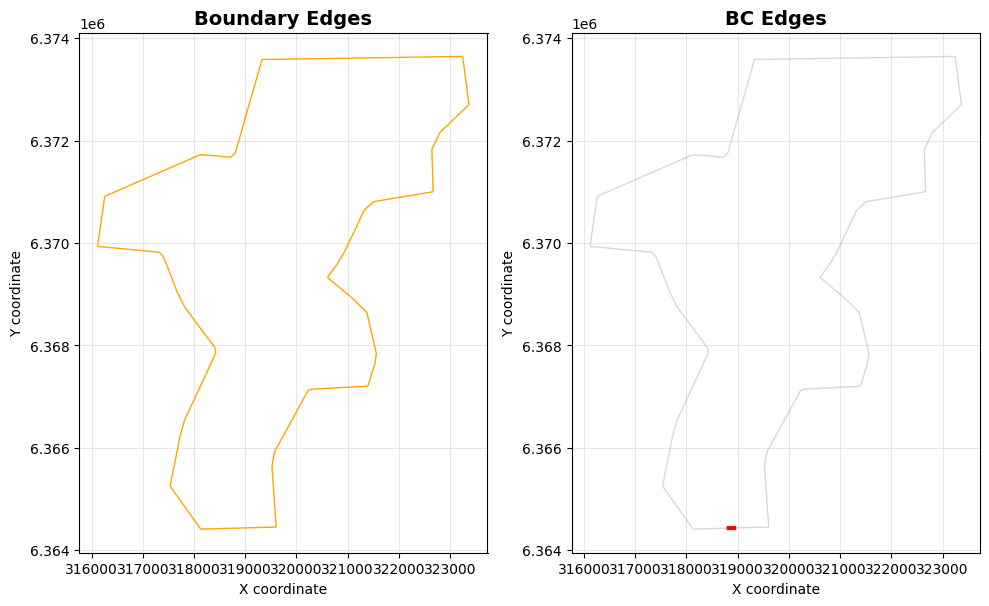

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10, 12))

ax1 = axes[0]
hec_boundary_edges = hec_edges_gdf[hec_edges_gdf['edge_type'] > 1]
hec_boundary_edges.plot(ax=ax1, color='orange', linewidth=1)
ax1.set_title('Boundary Edges', fontsize=14, fontweight='bold')
ax1.set_xlabel('X coordinate')
ax1.set_ylabel('Y coordinate')
ax1.grid(True, alpha=0.3)

ax2 = axes[1]
hec_bc_edges = hec_edges_gdf[hec_edges_gdf['edge_type'] == 2]
hec_boundary_edges.plot(ax=ax2, color='gray', linewidth=1, alpha=0.3)
hec_bc_edges.plot(ax=ax2, color='red', linewidth=3)
ax2.set_title('BC Edges', fontsize=14, fontweight='bold')
ax2.set_xlabel('X coordinate')
ax2.set_ylabel('Y coordinate')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Manual Coarse Mesh

In [15]:
def create_coarse_mesh_cluster(mesh_data: HECRASMeshData,
                               coarsening_factor=0.5,
                               random_state=42,
                               n_init=10):
    n_original = len(mesh_data.face_x)

    assert isinstance(coarsening_factor, float) and 0 < coarsening_factor < 1, \
        "coarsening_factor must be a float value between 0 and 1 representing the fraction of nodes to retain"
    n_coarse = max(3, int(n_original * coarsening_factor))
    print(f"Coarsening mesh from {n_original} to {n_coarse} faces (factor: {coarsening_factor})")

    # ==================== CREATE COARSE FACE CENTERS ======================
    face_center_coords = np.column_stack([mesh_data.face_x, mesh_data.face_y])
    kmeans = KMeans(n_clusters=n_coarse, random_state=random_state, n_init=n_init)
    cluster_labels = kmeans.fit_predict(face_center_coords)
    coarse_face_centers = kmeans.cluster_centers_

    # ===================== CREATE COARSE FACE NODES =======================
    # Map each mesh face center to its respective mesh face
    face_edges_gdf = mesh_data.to_faces_gdf()
    mesh_cells = face_edges_gdf.polygonize()
    spatial_index = mesh_cells.sindex
    matched_polygons = []
    for x, y in face_center_coords:
        center_point = Point((x, y))
        # Get candidate polygons using spatial index
        possible_matches_idx = list(spatial_index.intersection(center_point.bounds))
        possible_matches = mesh_cells.iloc[possible_matches_idx]
        # Find which polygon actually contains the point
        match_found = False
        for poly_geom in possible_matches.geometry:
            if poly_geom.contains(center_point):
                matched_polygons.append(poly_geom)
                match_found = True
                break
        assert match_found, f"No containing polygon found for node at {center_point}"
    mesh_cell_gdf = gpd.GeoDataFrame({
        'face_id': range(n_original),
        'cluster': cluster_labels,
    }, geometry=matched_polygons)

    # Find cluster boundaries and create shared nodes
    node_coords_dict = {}  # Maps (x, y) tuple to node index
    coarse_node_list = []
    cluster_boundary_nodes = {}  # Maps cluster_id to list of boundary node indices

    # Track original mesh boundary nodes
    original_boundary_nodes = set()
    if mesh_data.edge_type is not None:
        boundary_edge_mask = mesh_data.edge_type > 1
        boundary_edges = mesh_data.edge_index[:, boundary_edge_mask]
        original_boundary_nodes = set(boundary_edges.flatten())

    # Create nodes for each cluster
    for cluster_id in range(n_coarse):
        cluster_cells = mesh_cell_gdf[mesh_cell_gdf['cluster'] == cluster_id]

        # Merge polygons in cluster
        combined_polygon = unary_union(cluster_cells.geometry.tolist())
        assert combined_polygon.geom_type == 'Polygon', \
            f"Cluster {cluster_id} is disconnected (MultiPolygon). Consider different clustering parameters."

        # Extract boundary coordinates
        boundary_coords = list(combined_polygon.exterior.coords)[:-1]

        cluster_nodes = []
        for x, y in boundary_coords:
            coord_key = (round(x, 6), round(y, 6)) # Round to avoid floating point issues

            # Reuse existing node if coordinates match (shared boundary)
            if coord_key not in node_coords_dict:
                node_idx = len(coarse_node_list)
                node_coords_dict[coord_key] = node_idx
                coarse_node_list.append([x, y])
            else:
                node_idx = node_coords_dict[coord_key]

            cluster_nodes.append(node_idx)

        cluster_boundary_nodes[cluster_id] = cluster_nodes

    # ===================== CREATE COARSE FACE EDGES =======================
    # TODO: Fix logic for this one
    coarse_edges_list = []
    coarse_edge_types = []

    for cluster_id in range(n_coarse):
        cluster_nodes = cluster_boundary_nodes[cluster_id]
        n_nodes = len(cluster_nodes)

        for i in range(n_nodes):
            from_idx = cluster_nodes[i]
            to_idx = cluster_nodes[(i + 1) % n_nodes]
            edge = tuple(sorted([from_idx, to_idx]))
            coarse_edges_list.append([from_idx, to_idx])
            coarse_edge_types.append(1)

    # Remove duplicate edges (shared between clusters should only appear once)
    unique_edges = {}
    for edge, edge_type in zip(coarse_edges_list, coarse_edge_types):
        edge_tuple = tuple(sorted(edge))
        if edge_tuple not in unique_edges:
            unique_edges[edge_tuple] = edge_type

    # Rebuild edge lists with original orientation
    final_edges_list = []
    final_edge_types = []
    edge_set = set()

    for edge, edge_type in zip(coarse_edges_list, coarse_edge_types):
        edge_sorted = tuple(sorted(edge))
        if edge_sorted not in edge_set:
            edge_set.add(edge_sorted)
            final_edges_list.append(edge)
            final_edge_types.append(edge_type)

    # =================== CREATE COARSE FACE DUAL EDGES ====================
    neighbor_pairs = set()
    for link_idx in range(mesh_data.dual_edge_index.shape[1]):
        from_face, to_face = mesh_data.dual_edge_index[:, link_idx]
        
        if from_face >= 0 and to_face >= 0:  # Skip boundary dual edges
            from_cluster = cluster_labels[from_face]
            to_cluster = cluster_labels[to_face]
            
            if from_cluster != to_cluster:
                neighbor_pairs.add(tuple(sorted([from_cluster, to_cluster])))

    coarse_dual_edges_list = [[c1, c2] for c1, c2 in neighbor_pairs]

    # ==================== COARSE HECRAS MESH OBJECT ======================
    coarse_nodes = np.array(coarse_node_list)
    coarse_node_x = coarse_nodes[:, 0]
    coarse_node_y = coarse_nodes[:, 1]
    coarse_edge_index = np.array(final_edges_list).T if final_edges_list else np.zeros((2, 0), dtype=int)
    coarse_edge_type = np.array(final_edge_types, dtype=int) if final_edge_types else np.array([], dtype=int)
    coarse_face_x = coarse_face_centers[:, 0]
    coarse_face_y = coarse_face_centers[:, 1]
    coarse_dual_edge_index = np.array(coarse_dual_edges_list).T if coarse_dual_edges_list else np.zeros((2, 0), dtype=int)

    print(f"Created coarse mesh: {len(coarse_node_x)} nodes, {coarse_edge_index.shape[1]} edges, "
          f"{len(coarse_face_x)} faces, {coarse_dual_edge_index.shape[1]} dual edges")

    coarse_mesh_data = HECRASMeshData(
        node_x=coarse_node_x,
        node_y=coarse_node_y,
        edge_index=coarse_edge_index,
        edge_type=coarse_edge_type,
        face_x=coarse_face_x,
        face_y=coarse_face_y,
        dual_edge_index=coarse_dual_edge_index,
        face_nodes=None
    )

    return coarse_mesh_data


In [16]:
def plot_mesh(mesh_data: HECRASMeshData, figsize=(6, 6), show_faces=True, show_links=True, show_nodes=True):
    fig, ax = plt.subplots(figsize=figsize)

    if show_faces:
        faces_gdf = mesh_data.to_faces_gdf()
        if len(faces_gdf) > 0:
            faces_gdf.plot(ax=ax, color='black', linewidth=0.5, alpha=1)
    
    if show_links:
        links_gdf = mesh_data.to_edges_gdf()
        links_gdf.plot(ax=ax, color='red', linewidth=1, alpha=0.6)
    
    if show_nodes:
        nodes_gdf = mesh_data.to_nodes_gdf()
        nodes_gdf.plot(ax=ax, color='red', markersize=10, alpha=0.7)
    
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.tight_layout()
    plt.show()

In [17]:
coarse_mesh_data = create_coarse_mesh_cluster(
    mesh_data=mesh_data,
    coarsening_factor=0.5,
)

Coarsening mesh from 1126 to 563 faces (factor: 0.5)
Created coarse mesh: 1334 nodes, 1896 edges, 563 faces, 1319 dual edges


In [18]:
print('Shape of node_x:', coarse_mesh_data.node_x.shape)
print('Shape of node_y:', coarse_mesh_data.node_y.shape)
print('Shape of face_x:', coarse_mesh_data.face_x.shape)
print('Shape of face_y:', coarse_mesh_data.face_y.shape)
print('Shape of edge_index:', coarse_mesh_data.edge_index.shape)
print('Range of edge_index:', coarse_mesh_data.edge_index.min(), 'to', coarse_mesh_data.edge_index.max())
print('Shape of edge_type:', coarse_mesh_data.edge_type.shape)
print('Range of edge_type:', coarse_mesh_data.edge_type.min(), 'to', coarse_mesh_data.edge_type.max())
print('Shape of dual_edge_index:', coarse_mesh_data.dual_edge_index.shape)
print('Range of dual_edge_index:', coarse_mesh_data.dual_edge_index.min(), 'to', coarse_mesh_data.dual_edge_index.max())

Shape of node_x: (1334,)
Shape of node_y: (1334,)
Shape of face_x: (563,)
Shape of face_y: (563,)
Shape of edge_index: (2, 1896)
Range of edge_index: 0 to 1333
Shape of edge_type: (1896,)
Range of edge_type: 1 to 1
Shape of dual_edge_index: (2, 1319)
Range of dual_edge_index: 0 to 562


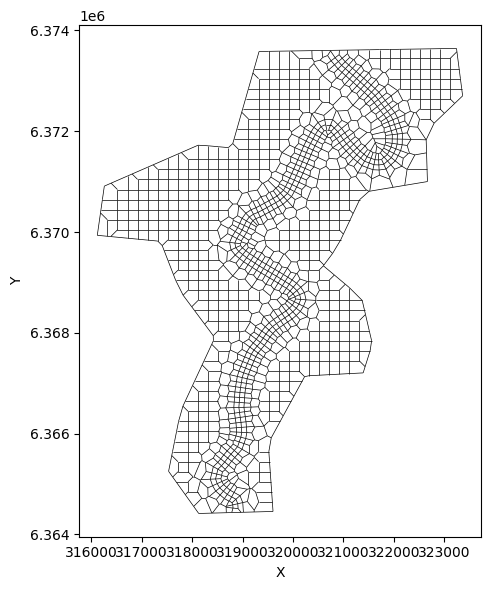

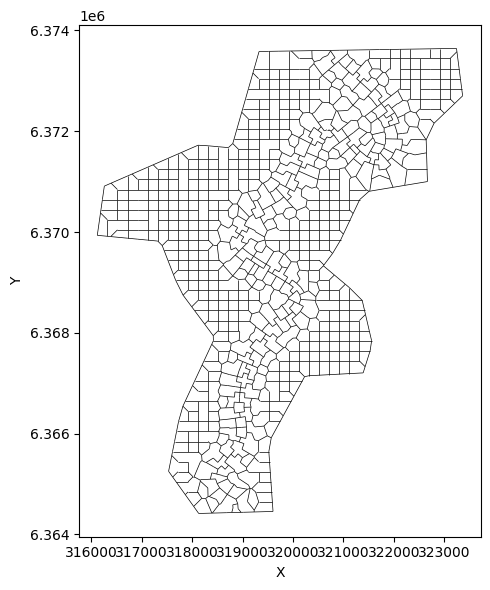

In [19]:
plot_mesh(mesh_data, show_links=False, show_nodes=False)
plot_mesh(coarse_mesh_data, show_links=False, show_nodes=False)

### MeshKernel

In [20]:
mesh_cells = face_edges_gdf.polygonize()
merged_polygon = unary_union(mesh_cells.to_list())
boundary_coords = list(merged_polygon.exterior.coords)

x_coords = np.array([coord[0] for coord in boundary_coords])
y_coords = np.array([coord[1] for coord in boundary_coords])

boundary_polygon = GeometryList(x_coords, y_coords)

In [21]:
def create_coarse_mesh_mk(boundary_polygon: GeometryList,
                          number_of_multiscales: int = 4,
                          min_edge_size: float = 0.5):
    meshes = []

    mk = MeshKernel()
    mk.mesh2d_make_triangular_mesh_from_polygon(boundary_polygon)

    for i in range(number_of_multiscales):
        mk.mesh2d_compute_orthogonalization(ProjectToLandBoundaryOption(0), OrthogonalizationParameters(
                    outer_iterations=25, boundary_iterations=25, inner_iterations=25, 
                    orthogonalization_to_smoothing_factor=0.975),
                    boundary_polygon, boundary_polygon)

        if i == number_of_multiscales-1:
            mk.mesh2d_delete_small_flow_edges_and_small_triangles(
            small_flow_edges_length_threshold=0.1, min_fractional_area_triangles=2.0)

        mesh = mk.mesh2d_get()
        meshes.append(mesh)

        # mesh = Mesh()
        # mesh._import_from_meshkernel(mk)
        # meshes.append(mesh)

        if i < number_of_multiscales-1:
            refinement_parameters = MeshRefinementParameters(refine_intersected=True, min_edge_size=min_edge_size, 
                                                        max_refinement_iterations=1, smoothing_iterations=5)
            mk.mesh2d_refine_based_on_polygon(boundary_polygon, refinement_parameters)
        
    return meshes

In [22]:
# Run create_coarse_mesh_mk
mk_meshes = create_coarse_mesh_mk(boundary_polygon,
                                  number_of_multiscales=4,
                                  min_edge_size=2)

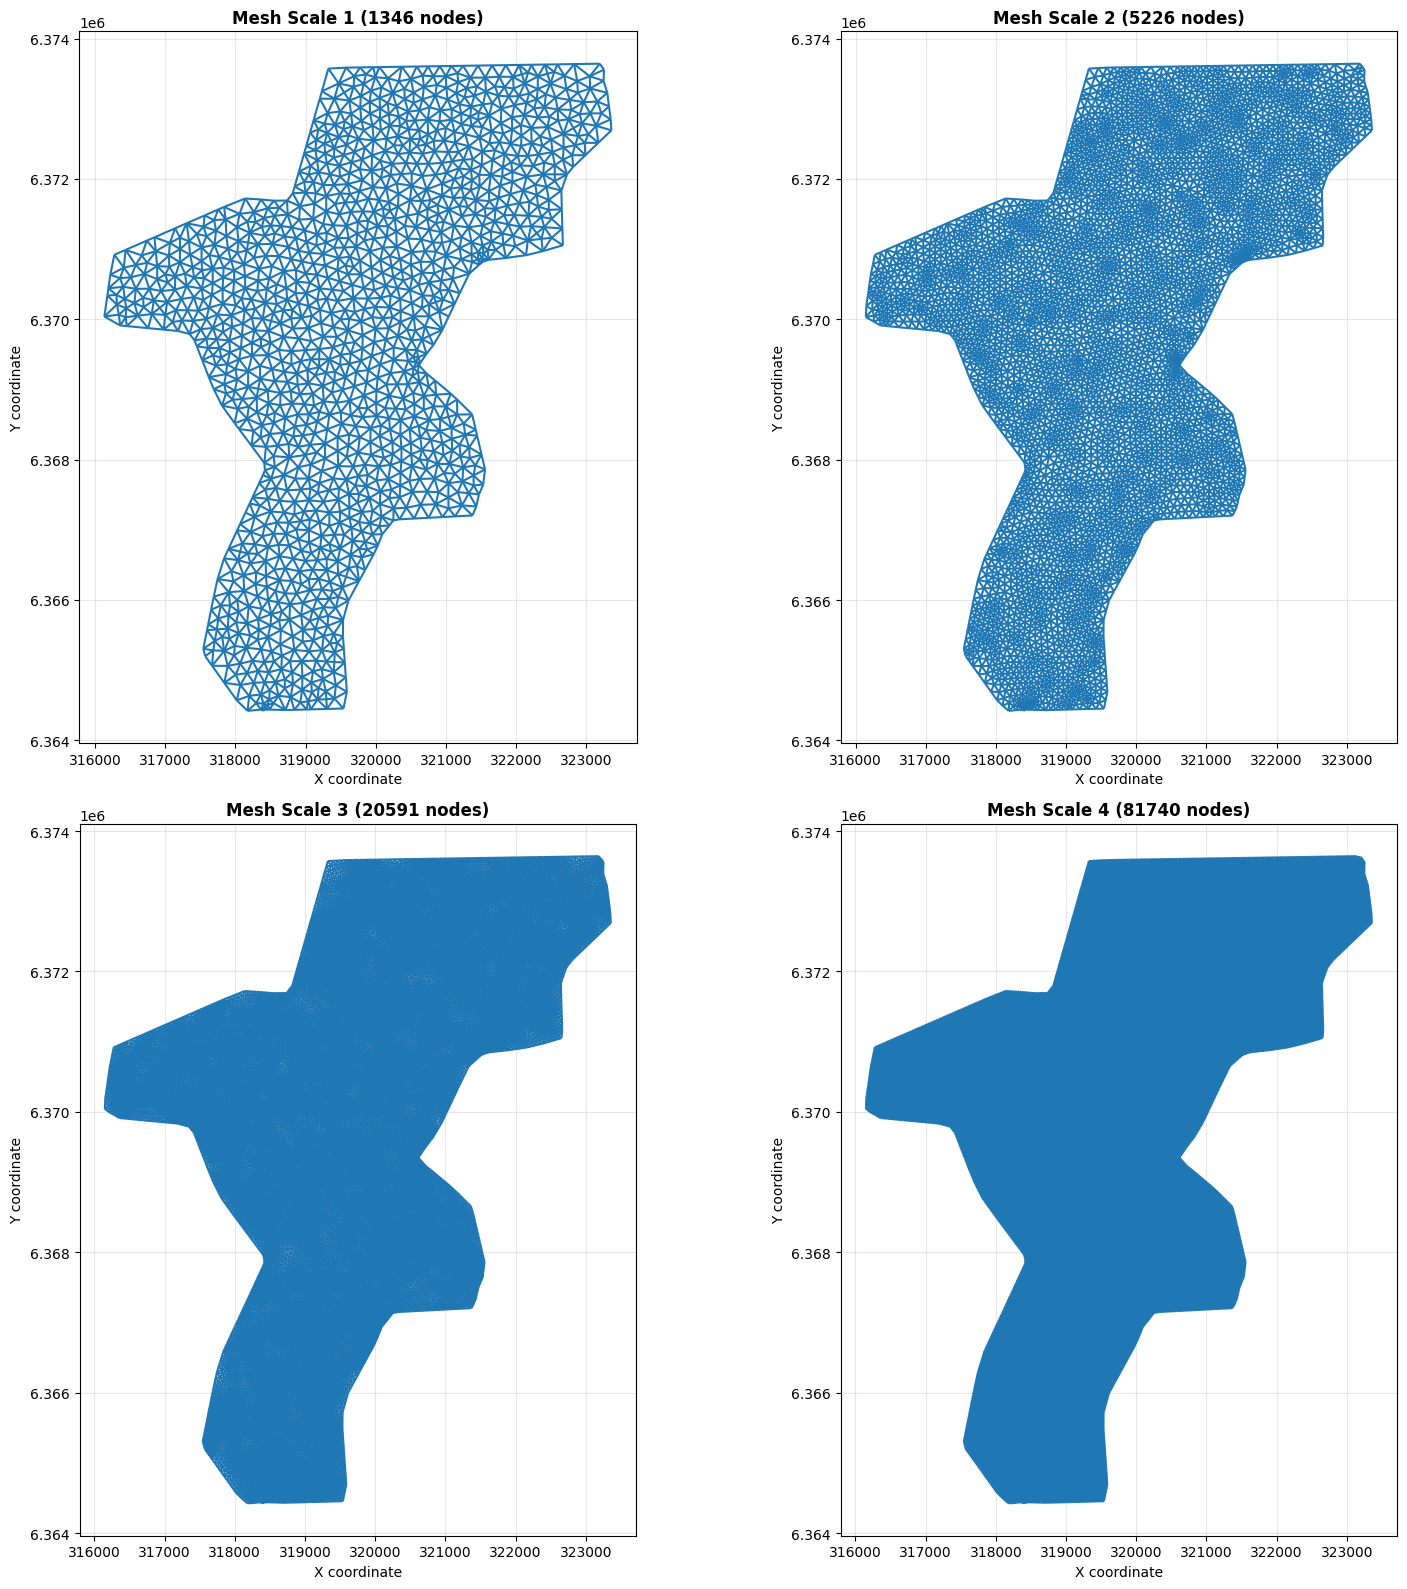

In [23]:
# Visualize the generated meshes
fig, axes = plt.subplots(2, 2, figsize=(16, 16))
axes = axes.flatten()

for i, mesh in enumerate(mk_meshes):
    ax = axes[i]

    # Plot edges
    mesh.plot_edges(ax=ax)
    
    # Extract node coordinates
    node_x = mesh.node_x
    ax.set_title(f'Mesh Scale {i+1} ({len(node_x)} nodes)', fontsize=12, fontweight='bold')
    ax.set_xlabel('X coordinate')
    ax.set_ylabel('Y coordinate')
    ax.grid(True, alpha=0.3)
    ax.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

### Triangle

In [24]:
mesh_cells = face_edges_gdf.polygonize()
merged_polygon = unary_union(mesh_cells.to_list())
boundary_coords = list(merged_polygon.exterior.coords)

# x_coords = np.array([coord[0] for coord in boundary_coords])
# y_coords = np.array([coord[1] for coord in boundary_coords])

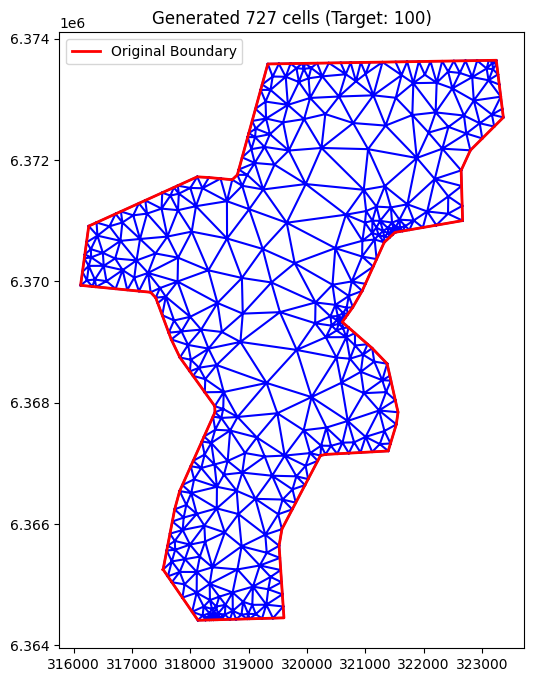

In [25]:
import triangle
import numpy as np
import matplotlib.pyplot as plt

def shoelace_area(points):
    """Calculate the area of a polygon using the shoelace formula."""
    x = points[:, 0]
    y = points[:, 1]
    return 0.5 * np.abs(np.dot(x, np.roll(y, 1)) - np.dot(y, np.roll(x, 1)))

# 1. Define your boundary points (Example: A simple square with a notch)
# In your case, you would load this from your existing mesh boundary
boundary_pts = np.array(boundary_coords)

# 2. Define segments (connecting point i to i+1)
N = len(boundary_pts)
segments = np.stack([np.arange(N), np.roll(np.arange(N), -1)], axis=1)

# 3. Calculate the 'max_area' for your target cell count
total_area = shoelace_area(boundary_pts)
target_cells = 100  # <--- SPECIFY YOUR DESIRED NUMBER OF CELLS HERE
calculated_max_area = total_area / target_cells

# 4. Create the dictionary input required by the triangle library
data = dict(vertices=boundary_pts, segments=segments)

# 5. Triangulate
# 'p': Triangulate a Polygon (respect boundary segments)
# 'q': Quality mesh (min angle constraint, usually 20 or 30 degrees)
# 'a': Maximum area constraint (followed by the number)
opts = f'pq30a{calculated_max_area:.4f}'

mesh = triangle.triangulate(data, opts)

# 6. Visualize
plt.figure(figsize=(6, 8))
plt.triplot(mesh['vertices'][:, 0], mesh['vertices'][:, 1], mesh['triangles'], 'b-')
plt.plot(boundary_pts[:, 0], boundary_pts[:, 1], 'r-', linewidth=2, label='Original Boundary')
plt.title(f"Generated {len(mesh['triangles'])} cells (Target: {target_cells})")
plt.legend()
plt.show()

### Multiscale Mesh Creation

In [26]:
def create_multiscale_meshes(mesh_data: HECRASMeshData,
                             coarsening_factor: float,
                             number_of_multiscales: int,
                             random_state: int = 42) -> list[HECRASMeshData]:
    multiscale_meshes = [mesh_data]
    current_mesh = mesh_data
    for _ in range(number_of_multiscales):
        coarse_mesh = create_coarse_mesh_cluster(
            mesh_data=current_mesh,
            coarsening_factor=coarsening_factor,
            random_state=random_state,
        )
        multiscale_meshes.append(coarse_mesh)
        current_mesh = coarse_mesh
    return multiscale_meshes

Coarsening mesh from 1126 to 563 faces (factor: 0.5)
Created coarse mesh: 1334 nodes, 1896 edges, 563 faces, 1319 dual edges
Coarsening mesh from 563 to 281 faces (factor: 0.5)
Created coarse mesh: 1176 nodes, 1456 edges, 281 faces, 720 dual edges
Coarsening mesh from 281 to 140 faces (factor: 0.5)
Created coarse mesh: 938 nodes, 1077 edges, 140 faces, 352 dual edges


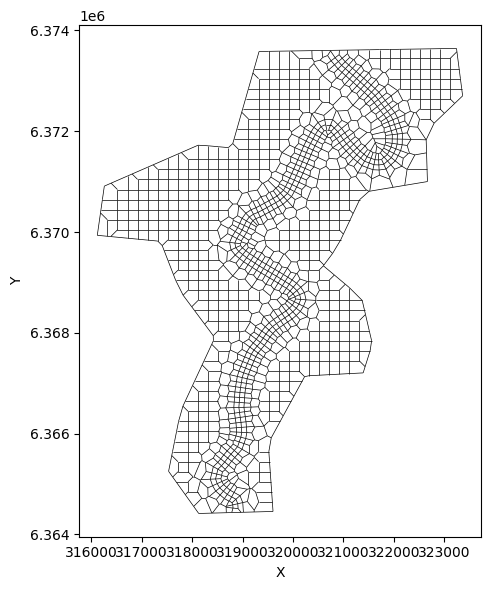

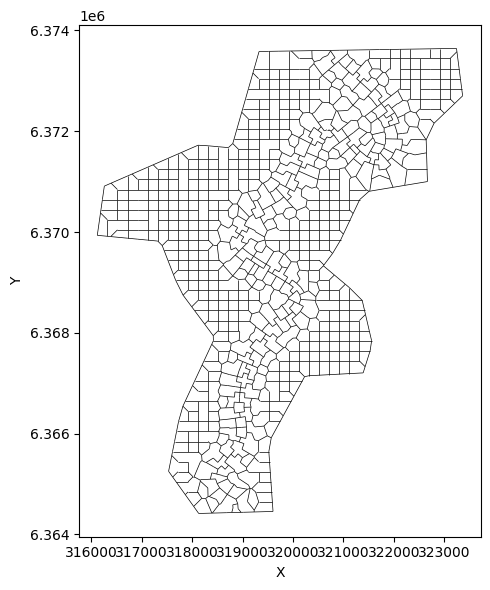

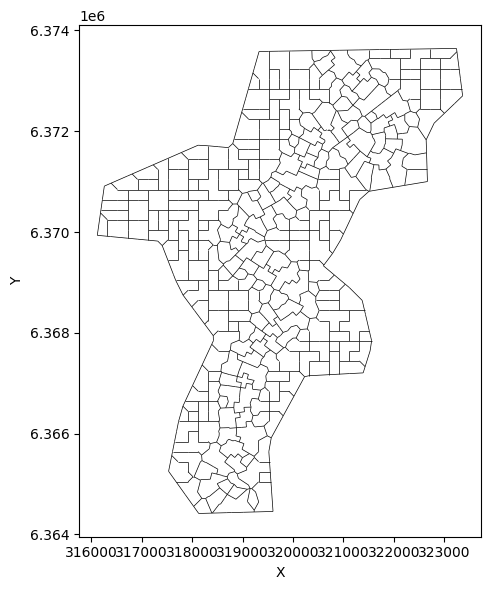

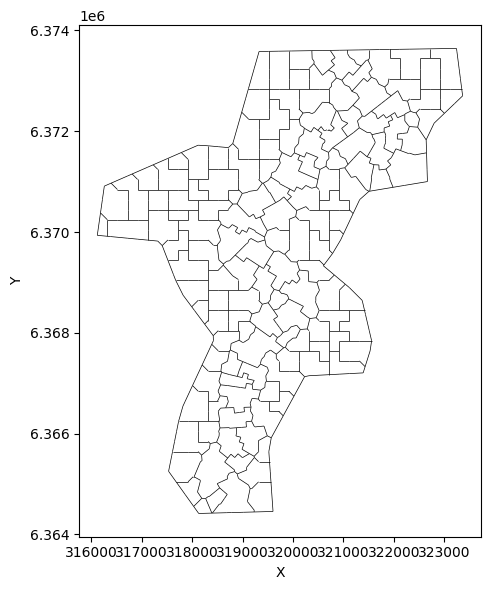

In [27]:
multiscale_meshes = create_multiscale_meshes(
    mesh_data=mesh_data,
    coarsening_factor=0.5,
    number_of_multiscales=3,
)

for mesh in multiscale_meshes:
    plot_mesh(mesh, show_links=False, show_nodes=False)